## Load Dataset

In [50]:
from google.colab import files
uploaded = files.upload()


Saving Sales Dataset.csv to Sales Dataset (1).csv


## Importing libary

In [53]:
import pandas as pd
df = pd.read_csv('Sales Dataset.csv')

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## Missing Values

In [13]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Identified 11 missing values in the Postal Code field (0.11% of records). All other variables were complete. Given the low proportion of missing values and the limited relevance of postal codes to sales performance analysis, the records were retained.

In [14]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [13]:
print(df.describe())

            Row ID   Postal Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  58103.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000


## Which Categories Generate the Most Sales?

In [15]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


## Which Sub-Categories Generate the Most Sales?

In [16]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
print(subcategory_sales.head(50))

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


## Which Regions Generate the Most Revenue?

In [17]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


## Which States Generate the Most Revenue?

In [18]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print(state_sales.head(50))

State
California              446306.4635
New York                306361.1470
Texas                   168572.5322
Washington              135206.8500
Pennsylvania            116276.6500
Florida                  88436.5320
Illinois                 79236.5170
Michigan                 76136.0740
Ohio                     75130.3500
Virginia                 70636.7200
North Carolina           55165.9640
Indiana                  48718.4000
Georgia                  48219.1100
Kentucky                 36458.3900
Arizona                  35272.6570
New Jersey               34610.9720
Colorado                 31841.5980
Wisconsin                31173.4300
Tennessee                30661.8730
Minnesota                29863.1500
Massachusetts            28634.4340
Delaware                 27322.9990
Maryland                 23705.5230
Rhode Island             22525.0260
Missouri                 22205.1500
Oklahoma                 19683.3900
Alabama                  19510.6400
Oregon                

## Which Customer Segments Spend the Most?

In [19]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


## Top 50 Products by Sales

In [20]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
print(top_products.head(50))

Product Name
Canon imageCLASS 2200 Advanced Copier                                                         61599.8240
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind                   27453.3840
Cisco TelePresence System EX90 Videoconferencing Unit                                         22638.4800
HON 5400 Series Task Chairs for Big and Tall                                                  21870.5760
GBC DocuBind TL300 Electric Binding System                                                    19823.4790
GBC Ibimaster 500 Manual ProClick Binding System                                              19024.5000
Hewlett Packard LaserJet 3310 Copier                                                          18839.6860
HP Designjet T520 Inkjet Large Format Printer - 24" Color                                     18374.8950
GBC DocuBind P400 Electric Binding System                                                     17965.0680
High Speed Automatic Electric Letter Opene

In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [25]:
print(df['Order Date'].dtype)

datetime64[ns]


## Monthly Sales Trend

In [26]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

print(monthly_sales)

Order Date
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040


## Sales Visualization

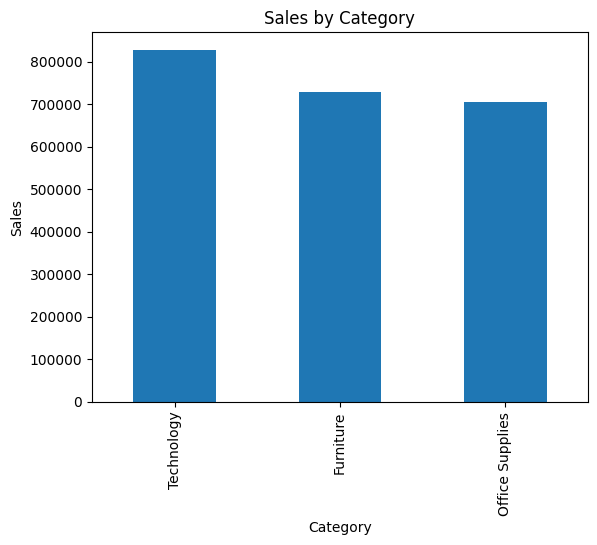

In [27]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.ylabel('Sales')
plt.xlabel('Category')
plt.show()

**Analyzed Superstore 9,800 retail transactions Data using Python libary identifying key sales trends across customer segments, product categories, and geographic regions. Developed visualizations and business recommendations based on revenue performance and customer purchasing behavior.**

In [29]:
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


## Insight for managment

**Technology products are the primary revenue driver for the business. Management should consider prioritizing inventory availability, marketing campaigns, and customer retention strategies for this category to sustain revenue growth.**

In [30]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


## BUSINESS INSIGHT
The Corporate segment generated the highest sales revenue, indicating that business customers are a key source of income for the company. The Consumer segment contributed the lowest revenue, suggesting potential opportunities to improve engagement.

## Analyze Regions

In [40]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


The West region generated the highest sales revenue, indicating strong market demand and customer engagement. The South region recorded the lowest sales, suggesting an opportunity for targeted marketing campaigns and sales growth initiatives.

## Analyze States

In [41]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print(state_sales.head(50))

State
California              446306.4635
New York                306361.1470
Texas                   168572.5322
Washington              135206.8500
Pennsylvania            116276.6500
Florida                  88436.5320
Illinois                 79236.5170
Michigan                 76136.0740
Ohio                     75130.3500
Virginia                 70636.7200
North Carolina           55165.9640
Indiana                  48718.4000
Georgia                  48219.1100
Kentucky                 36458.3900
Arizona                  35272.6570
New Jersey               34610.9720
Colorado                 31841.5980
Wisconsin                31173.4300
Tennessee                30661.8730
Minnesota                29863.1500
Massachusetts            28634.4340
Delaware                 27322.9990
Maryland                 23705.5230
Rhode Island             22525.0260
Missouri                 22205.1500
Oklahoma                 19683.3900
Alabama                  19510.6400
Oregon                

California and New York are the company's strongest markets, contributing significantly to total revenue. Management should maintain investment in these regions while exploring growth opportunities in lower-performing states.

## Analyze Product Performance

In [42]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(top_products.head(50))

Product Name
Canon imageCLASS 2200 Advanced Copier                                                         61599.8240
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind                   27453.3840
Cisco TelePresence System EX90 Videoconferencing Unit                                         22638.4800
HON 5400 Series Task Chairs for Big and Tall                                                  21870.5760
GBC DocuBind TL300 Electric Binding System                                                    19823.4790
GBC Ibimaster 500 Manual ProClick Binding System                                              19024.5000
Hewlett Packard LaserJet 3310 Copier                                                          18839.6860
HP Designjet T520 Inkjet Large Format Printer - 24" Color                                     18374.8950
GBC DocuBind P400 Electric Binding System                                                     17965.0680
High Speed Automatic Electric Letter Opene

High-value technology products generate substantial revenue. The company should prioritize inventory availability and customer support for these products to maximize sales opportunities.

## Analyze Sales Trend Over Time

In [43]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [44]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
      .sum()
)
print(monthly_sales)

Order Date
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040


Sales consistently peak during the final quarter of the year, particularly in November. This suggests seasonal demand and highlights the importance of inventory planning and promotional campaigns ahead of peak periods.

In [45]:
import os
os.makedirs('images', exist_ok=True)

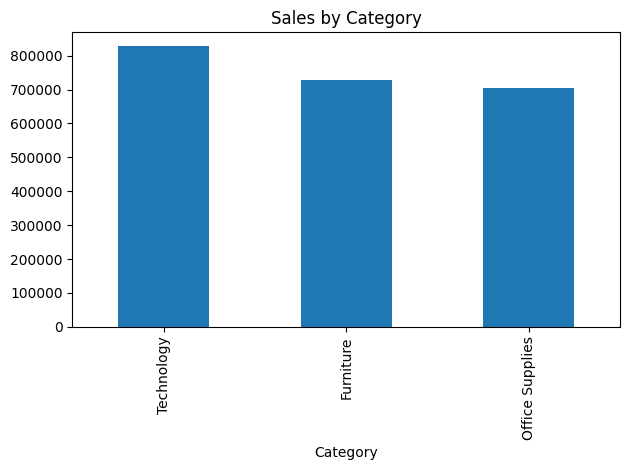

In [46]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.tight_layout()
plt.savefig('images/category_sales.png')
plt.show()

# Visualizations

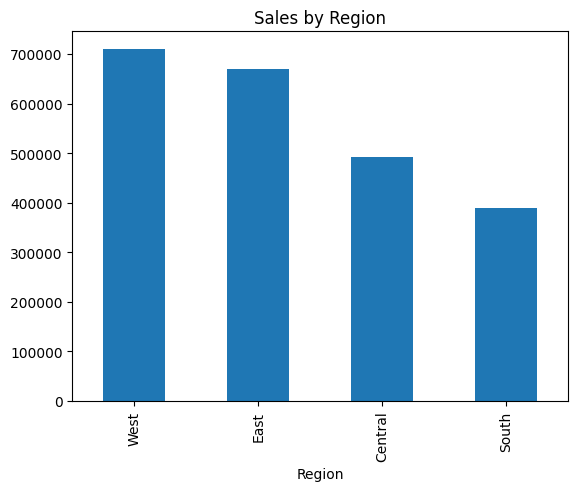

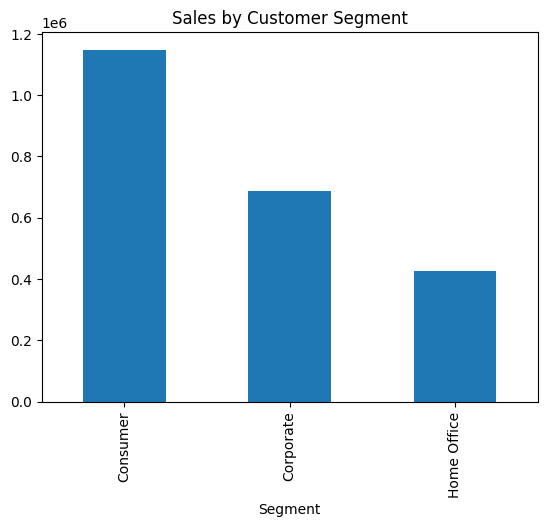

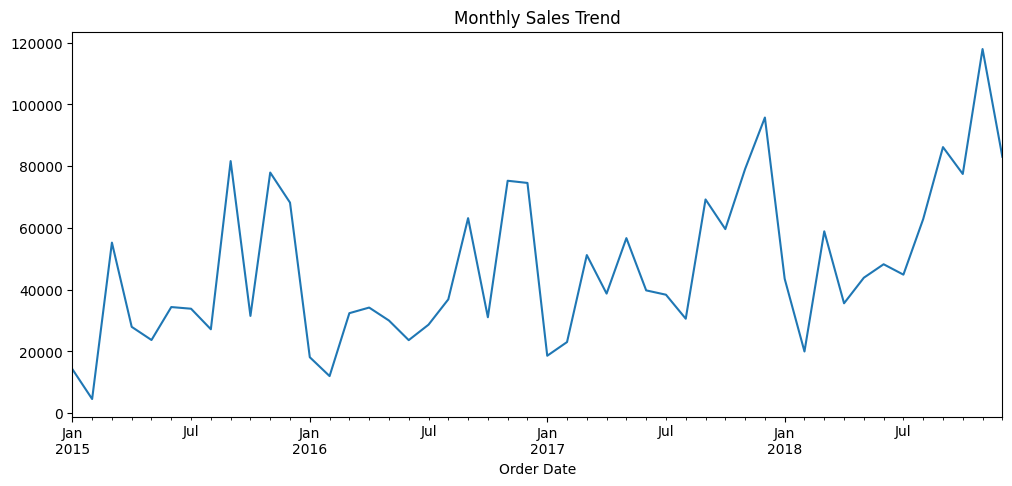

In [47]:
# Region Sales
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.show()

# Segment Sales
segment_sales.plot(kind='bar')
plt.title('Sales by Customer Segment')
plt.show()

# Monthly Trend
monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.show()

In [48]:
import os
print(os.listdir('images'))

['category_sales.png']
